# 04 · Clusterização de bairros

Os notebooks anteriores mediram **uma relação**: bairros com crime proporcionalmente mais violento têm metro quadrado mais barato. Uma correlação resume isso num único número e, ao fazer isso, esconde os tipos de bairro que existem.

Este notebook pergunta outra coisa: **que perfis de bairro a cidade tem?** Em vez de impor eixos, deixa o algoritmo agrupar os 430 bairros por semelhança e depois lê o que cada grupo significa.

A intuição a testar é que existiriam quatro tipos — caro com pouca violência, caro com muita, barato com pouca, barato com muita. Um corte pelas medianas mostra que os quatro quadrantes de fato têm bairros dentro:

| | muita violência | pouca violência |
|---|---|---|
| **caro** | 60 bairros | 155 bairros |
| **barato** | 155 bairros | 60 bairros |

Mas "ter bairros dentro de um quadrante" não é a mesma coisa que "ser um tipo de bairro". Os quadrantes vêm de dois cortes arbitrários na mediana; um cluster só existe se os bairros realmente se parecerem entre si e se distinguirem dos outros. A seção 6 confronta as duas coisas.

**Importante sobre o que clusterização é e não é:** ela não testa hipótese nem prova nada. É descrição — um jeito de organizar 430 linhas em poucos grupos legíveis. Não há resposta "certa" para o número de clusters, e grupos diferentes apareceriam com outras variáveis. O valor está em os grupos serem *nomeáveis* e *reconhecíveis* por quem conhece a cidade.

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from scipy.cluster import hierarchy
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pio.renderers.default = "plotly_mimetype"

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
CACHE = RAIZ / "data" / "SP" / "cache"

bairros = pd.read_parquet(CACHE / "bairros.parquet")
MES_REFERENCIA = (CACHE / "mes_referencia.txt").read_text(encoding="utf-8").strip()

AZUL, LARANJA, AQUA, VIOLETA = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
SUPERFICIE, TINTA, TINTA2, MUDO, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
DIVERGENTE = LinearSegmentedColormap.from_list("div", [AZUL, "#f0efec", "#e34948"])
CORES = [AZUL, LARANJA, AQUA, VIOLETA]

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelcolor": TINTA2, "axes.labelsize": 10,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 8,
})


def reais(valor, _=None):
    return f"R$ {valor:,.0f}".replace(",", ".")


FORMATO_REAIS = FuncFormatter(reais)
print(f"{len(bairros)} bairros · preços em reais constantes de {MES_REFERENCIA}")

431 bairros · preços em reais constantes de 2026-08


## 1 · As variáveis e por que padronizar

Seis variáveis, escolhidas para cobrir três dimensões diferentes de um bairro:

| variável | dimensão |
|---|---|
| `preco_m2_mediano` | preço |
| `share_violento` | **composição** do crime |
| `log_crimes_total` | **exposição** — volume absoluto de ocorrências |
| `log_violentos_por_1k` | violência normalizada pelo estoque imobiliário |
| `area_mediana` | tipo de imóvel |
| `idade_mediana` | idade do estoque construído |

As duas medidas de crime separadas — composição e exposição — são o que permite o algoritmo distinguir "bairro movimentado onde se furta muito" de "bairro tranquilo onde o pouco que acontece é violento". Essa distinção foi o achado central do notebook 02, e aqui ela é dada ao algoritmo como matéria-prima.

**Padronizar é obrigatório, não cosmético.** O `KMeans` agrupa por distância euclidiana. Sem padronizar, `preco_m2_mediano` varia de 980 a 14.900 e `share_violento` de 0 a 1 — a distância entre dois bairros seria essencialmente a diferença de preço, e as outras cinco variáveis não existiriam para o algoritmo. O `StandardScaler` põe todas em média 0 e desvio 1, de modo que cada uma pese igual.

In [2]:
VARIAVEIS = {
    "preco_m2_mediano": "preço do m² (real)",
    "share_violento": "% de crimes violentos",
    "log_crimes_total": "volume de crimes (log)",
    "log_violentos_por_1k": "violentos por mil transações (log)",
    "area_mediana": "área construída mediana",
    "idade_mediana": "idade mediana do imóvel",
}

dados = bairros.dropna(subset=list(VARIAVEIS)).copy()
escalador = StandardScaler().fit(dados[list(VARIAVEIS)])
X = escalador.transform(dados[list(VARIAVEIS)])

print(f"{len(dados)} bairros sem nulos nas seis variáveis (de {len(bairros)})")
dados[list(VARIAVEIS)].describe().T[["min", "50%", "max"]].round(2)

431 bairros sem nulos nas seis variáveis (de 431)


,min,50%,max
preco_m2_mediano,982.67,4073.63,14891.68
share_violento,0.10,0.40,0.67
log_crimes_total,1.49,2.14,4.08
log_violentos_por_1k,0.85,2.42,4.59
area_mediana,49.00,103.00,472.00
idade_mediana,2.00,24.00,60.00


## 2 · Quantos clusters?

Não existe resposta objetiva, mas existem dois indicadores que, juntos, limitam o chute:

- **Silhueta** — mede, para cada bairro, se ele está mais perto dos bairros do próprio grupo do que dos do grupo vizinho. Vai de −1 a 1; quanto mais alto, melhor separados os grupos. **Tem máximo**, então serve para escolher.
- **Inércia** — soma das distâncias ao centroide do próprio cluster. Cai sempre que se acrescenta um cluster, então nunca tem máximo; serve para procurar o "joelho", o ponto depois do qual acrescentar grupo para de compensar.

Os dois aparecem em painéis separados, não num gráfico de dois eixos y — duas escalas no mesmo gráfico deixariam escolher visualmente onde está o joelho só mexendo nos limites dos eixos.

,silhueta,inércia
k,,
2,0.250,2060.465
3,0.276,1636.810
4,0.255,1409.197
5,0.217,1240.607
6,0.225,1132.756
7,0.219,1051.876
8,0.228,984.924
9,0.198,926.814
10,0.199,866.178


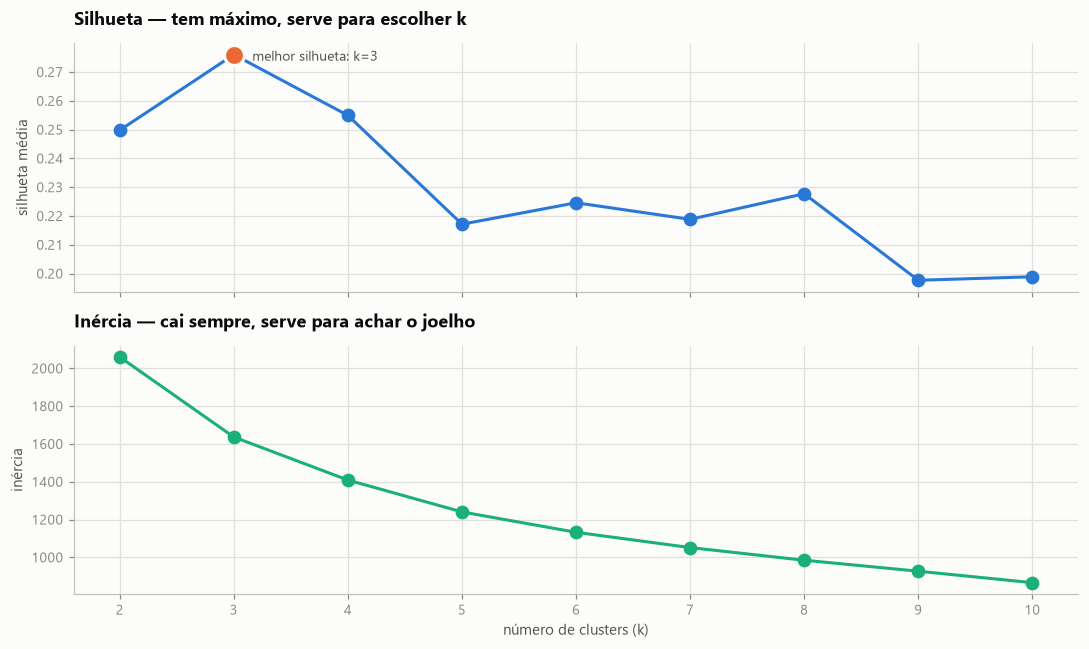

In [3]:
FAIXA_K = range(2, 11)

diagnostico = pd.DataFrame(
    [
        {
            "k": k,
            "silhueta": silhouette_score(X, rotulos),
            "inércia": modelo.inertia_,
        }
        for k in FAIXA_K
        for modelo in [KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)]
        for rotulos in [modelo.labels_]
    ]
).set_index("k")

K_MELHOR = int(diagnostico["silhueta"].idxmax())

fig, eixos = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

eixos[0].plot(diagnostico.index, diagnostico["silhueta"], color=AZUL, marker="o")
eixos[0].plot(K_MELHOR, diagnostico.loc[K_MELHOR, "silhueta"], "o", color=LARANJA, markersize=13,
              markeredgecolor=SUPERFICIE, markeredgewidth=2)
eixos[0].annotate(f"melhor silhueta: k={K_MELHOR}",
                  (K_MELHOR, diagnostico.loc[K_MELHOR, "silhueta"]),
                  xytext=(12, -4), textcoords="offset points", color=TINTA2, fontsize=9)
eixos[0].set(title="Silhueta — tem máximo, serve para escolher k", ylabel="silhueta média")

eixos[1].plot(diagnostico.index, diagnostico["inércia"], color=AQUA, marker="o")
eixos[1].set(title="Inércia — cai sempre, serve para achar o joelho",
             xlabel="número de clusters (k)", ylabel="inércia")
eixos[1].set_xticks(list(FAIXA_K))

plt.tight_layout()
diagnostico.round(3)

### Validação cruzada: agrupamento hierárquico

A silhueta é um critério; vale conferir com um algoritmo de lógica diferente. O **agrupamento hierárquico de Ward** não precisa de k definido de antemão: ele funde os dois grupos mais parecidos, repetidamente, e o dendrograma mostra a que distância cada fusão aconteceu.

O que procurar: **saltos grandes na altura**. Um salto significa que a fusão juntou coisas muito diferentes, ou seja, que o número de grupos imediatamente antes dela era significativo. Se o maior salto do dendrograma estiver no mesmo k que a silhueta escolheu, os dois métodos concordam.

k com maior salto no dendrograma: 4
k com melhor silhueta no KMeans:  3


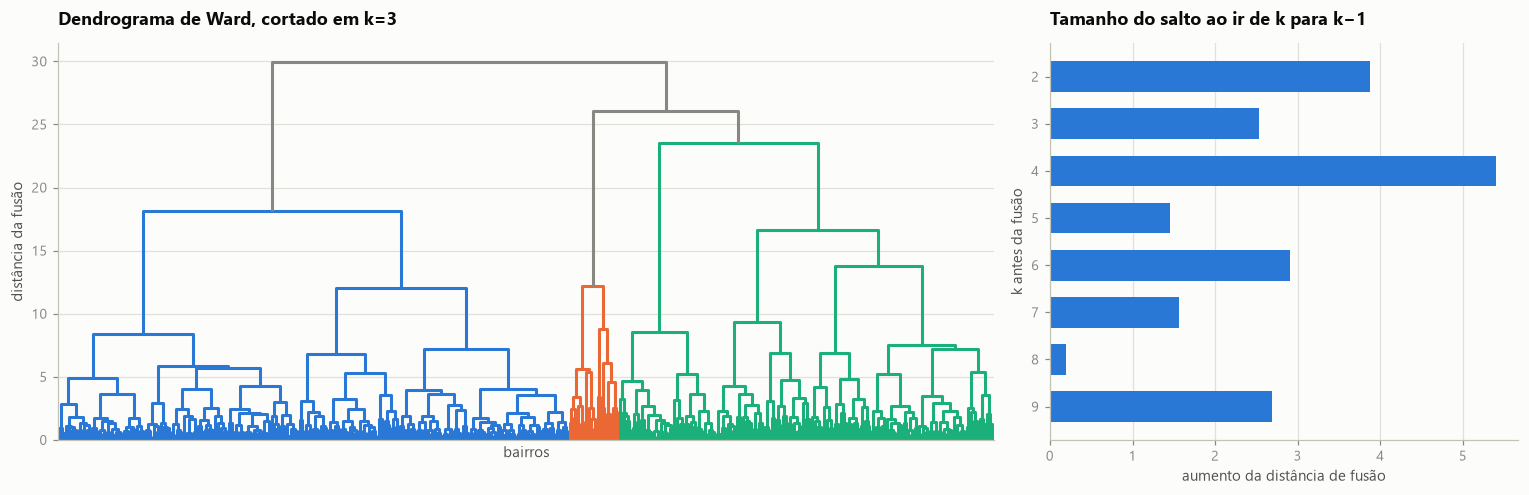

In [4]:
ligacao = hierarchy.linkage(X, method="ward")

fig, (esq, drt) = plt.subplots(1, 2, figsize=(14, 4.6), width_ratios=[2, 1])

hierarchy.set_link_color_palette([AZUL, LARANJA, AQUA, VIOLETA])
hierarchy.dendrogram(
    ligacao, ax=esq, no_labels=True, color_threshold=ligacao[-(K_MELHOR - 1), 2],
    above_threshold_color=MUDO,
)
esq.set(title=f"Dendrograma de Ward, cortado em k={K_MELHOR}",
        xlabel="bairros", ylabel="distância da fusão")
esq.grid(axis="x", visible=False)

alturas = ligacao[-9:, 2]
saltos = pd.Series(np.diff(alturas), index=range(10, 1, -1)[1:])
drt.barh(saltos.index.astype(str), saltos.to_numpy(), color=AZUL, height=0.65)
drt.set(title="Tamanho do salto ao ir de k para k−1", xlabel="aumento da distância de fusão",
        ylabel="k antes da fusão")
drt.grid(axis="y", visible=False)

plt.tight_layout()
print(f"k com maior salto no dendrograma: {int(saltos.idxmax())}")
print(f"k com melhor silhueta no KMeans:  {K_MELHOR}")

## 3 · Ajustando os dois agrupamentos

O escolhido pela silhueta e também `k=4`, para confrontar diretamente a intuição dos quatro tipos de bairro.

Os rótulos que o `KMeans` devolve são arbitrários — "cluster 0" não significa nada e muda entre execuções. Por isso os clusters são **renumerados por preço mediano crescente**, o que torna a leitura estável e comparável entre os dois agrupamentos.

In [5]:
def agrupa(matriz, k):
    rotulos = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(matriz)
    ordem = (
        pd.Series(dados["preco_m2_mediano"].to_numpy())
        .groupby(rotulos)
        .median()
        .sort_values()
        .index
    )
    renumera = {antigo: novo for novo, antigo in enumerate(ordem)}
    return pd.Series(rotulos, index=dados.index).map(renumera)


for k in sorted({K_MELHOR, 4}):
    dados[f"cluster_{k}"] = agrupa(X, k)

COLUNA_PRINCIPAL = f"cluster_{K_MELHOR}"
dados[[c for c in dados.columns if c.startswith("cluster_")]].apply(
    lambda s: s.value_counts().sort_index()
).fillna(0).astype(int).rename_axis("cluster")

,cluster_3,cluster_4
cluster,,
0,247,79
1,109,217
2,75,111
3,0,24


## 4 · O que cada cluster é

Esta é a parte que dá sentido ao exercício. O heatmap mostra, para cada cluster, a **média padronizada** de cada variável — ou seja, quantos desvios-padrão acima ou abaixo da média da cidade aquele grupo está. Azul é abaixo da média, vermelho acima, cinza em cima da média. É por isso que a rampa é divergente com cinza no meio: aqui o zero significa "igual à cidade", e tem que parecer neutro.

Abaixo do heatmap, uma etiqueta gerada automaticamente lista as duas variáveis em que cada cluster mais se destaca, com o sinal. Ela é objetiva — sai direto dos números, sem interpretação minha — e serve de base para os nomes em prosa que vêm depois.

Etiqueta automática de cada cluster (as duas variáveis mais destacadas):
  cluster 0: volume de crimes (log) baixo · % de crimes violentos alto
  cluster 1: volume de crimes (log) alto · violentos por mil transações (log) alto
  cluster 2: preço do m² (real) alto · área construída mediana alto


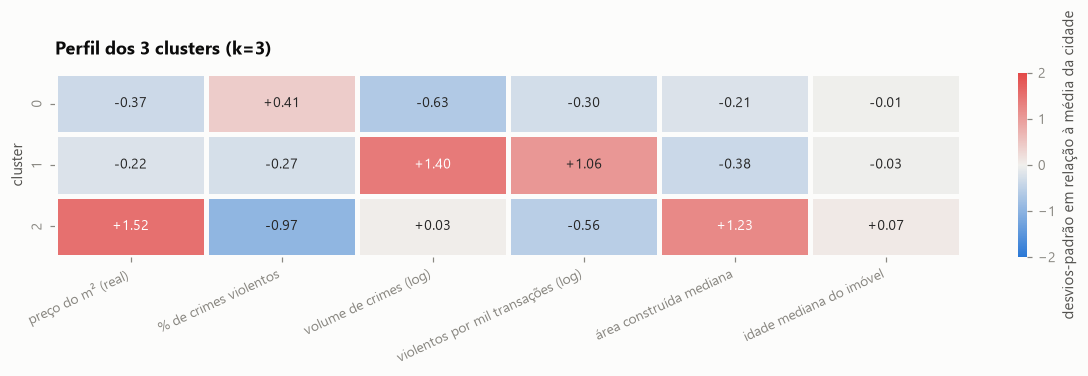

In [6]:
def perfil_padronizado(coluna):
    padronizado = pd.DataFrame(X, index=dados.index, columns=list(VARIAVEIS))
    return padronizado.groupby(dados[coluna]).mean()


def etiqueta(linha, quantas=2):
    destaques = linha.abs().nlargest(quantas).index
    return " · ".join(
        f"{VARIAVEIS[v]} {'alto' if linha[v] > 0 else 'baixo'}" for v in destaques
    )


perfil = perfil_padronizado(COLUNA_PRINCIPAL)

fig, eixo = plt.subplots(figsize=(11, 1 + 0.75 * len(perfil)))
sns.heatmap(
    perfil.rename(columns=VARIAVEIS), cmap=DIVERGENTE, center=0, vmin=-2, vmax=2,
    annot=True, fmt="+.2f", annot_kws={"size": 9}, linewidths=2, linecolor=SUPERFICIE,
    cbar_kws={"label": "desvios-padrão em relação à média da cidade"}, ax=eixo,
)
eixo.set(title=f"Perfil dos {len(perfil)} clusters (k={K_MELHOR})", xlabel="", ylabel="cluster")
plt.setp(eixo.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()

print("Etiqueta automática de cada cluster (as duas variáveis mais destacadas):")
for c, linha in perfil.iterrows():
    print(f"  cluster {c}: {etiqueta(linha)}")

In [7]:
RESUMO = {
    "bairros": ("preco_m2_mediano", "size"),
    "R$/m² mediano": ("preco_m2_mediano", "median"),
    "% violento": ("share_violento", "mean"),
    "crimes/ano": ("crimes_total", "median"),
    "violentos/1k": ("violentos_por_1k", "median"),
    "área (m²)": ("area_mediana", "median"),
    "idade (anos)": ("idade_mediana", "median"),
    "transações": ("n_transacoes", "sum"),
}


def tabela_resumo(coluna):
    return dados.groupby(coluna).agg(**RESUMO)


tabela_resumo(COLUNA_PRINCIPAL).style.format({
    "bairros": "{:,.0f}", "R$/m² mediano": "R$ {:,.0f}", "% violento": "{:.1%}",
    "crimes/ano": "{:,.0f}", "violentos/1k": "{:,.0f}", "área (m²)": "{:,.0f}",
    "idade (anos)": "{:,.0f}", "transações": "{:,.0f}",
}).set_caption("Perfil dos clusters em unidades originais")

,bairros,R$/m² mediano,% violento,crimes/ano,violentos/1k,área (m²),idade (anos),transações
cluster_3,,,,,,,,
0,247,"R$ 3,875",43.9%,74,207,100,24,"67,893"
1,109,"R$ 4,056",36.2%,"2,590","1,401",97,22,"159,721"
2,75,"R$ 6,655",28.4%,227,135,143,23,"84,634"


In [8]:
def representativos(coluna, quantos=6):
    padronizado = pd.DataFrame(X, index=dados.index, columns=list(VARIAVEIS))
    centroides = padronizado.groupby(dados[coluna]).mean()
    distancia = pd.Series(
        np.linalg.norm(padronizado.to_numpy() - centroides.loc[dados[coluna]].to_numpy(), axis=1),
        index=dados.index,
    )
    return (
        distancia.groupby(dados[coluna])
        .nsmallest(quantos)
        .reset_index(level=0, drop=True)
        .groupby(dados[coluna])
        .apply(lambda s: ", ".join(s.index.str.title()))
        .rename("bairros mais típicos do cluster")
    )


representativos(COLUNA_PRINCIPAL).to_frame()

,bairros mais típicos do cluster
cluster_3,
0,"Vila Butanta, Vila Bancaria, Vila Palmeiras, P..."
1,"Vila Maria, Freguesia Do O, Cachoeirinha, Penh..."
2,"Vila Romana, Pompeia, Alto Da Lapa, Paraiso, B..."


### Os três tipos de bairro, com nome

Juntando o heatmap, a tabela em unidades originais e os bairros típicos, os três grupos ficam assim:

**Cluster 0 — bairro residencial miúdo** · 244 bairros (57% da cidade) · R$ 3.875/m²
*Vila Butantã, Vila Bancária, Vila Palmeiras, Parque Peruche, Vila Buenos Aires*
Pouquíssimo crime em volume absoluto — **74 ocorrências por ano**, o menor dos três — e ao mesmo tempo a **maior fração violenta: 44%**. São bairros pequenos, essencialmente residenciais, onde pouca coisa acontece, mas o que acontece é proporcionalmente mais grave. É o tipo mais comum de bairro de São Paulo.

**Cluster 1 — distrito populoso de alto fluxo** · 109 bairros · R$ 4.017/m²
*Cachoeirinha, Vila Maria, Freguesia do Ó, Penha, Limão, Cangaíba*
**2.586 ocorrências por ano** — 35 vezes mais que o cluster 0 — e preço praticamente idêntico a ele (diferença de 3,7%). São os grandes distritos populosos, com comércio de rua, terminal de ônibus e muita circulação.

**Cluster 2 — miolo valorizado** · 77 bairros · R$ 6.589/m²
*Vila Romana, Pompeia, Paraíso, Vila Clementino, Brooklin Paulista, Alto da Lapa*
Preço 70% acima dos outros dois, a **menor fração violenta (29%)** e os maiores imóveis (143 m² contra ~98 m²). Volume de crime intermediário: 236 por ano.

### O que a comparação entre os clusters 0 e 1 prova

Os dois têm preço praticamente igual — R$ 3.875 e R$ 4.017 — e volume de crime que difere **35 vezes**. É a demonstração mais direta possível do achado dos notebooks anteriores: **contar ocorrências não diz nada sobre preço**. Se contagem de crime derrubasse preço, o cluster 1 teria que ser drasticamente mais barato que o cluster 0. Não é.

E o que *ordena* o preço dos três grupos é a fração violenta, que cai monotonicamente conforme o preço sobe: **44% → 37% → 29%**.

Note também que foi o algoritmo quem organizou a cidade assim, com seis variáveis e sem saber que preço e violência eram as de interesse. Ele escolheu separar os bairros não-caros por **tamanho e fluxo**, não por violência — o que já antecipa o resultado da próxima seção.

## 5 · Os clusters no plano preço × violência

Este é o gráfico que responde direto à intuição de partida. Os eixos são os dois que a hipótese usava; as cores são os clusters, que o algoritmo formou **sem** saber que esses dois eixos eram os de interesse.

Cada centroide recebe rótulo direto no gráfico, além da legenda — identidade nunca depende só de cor.

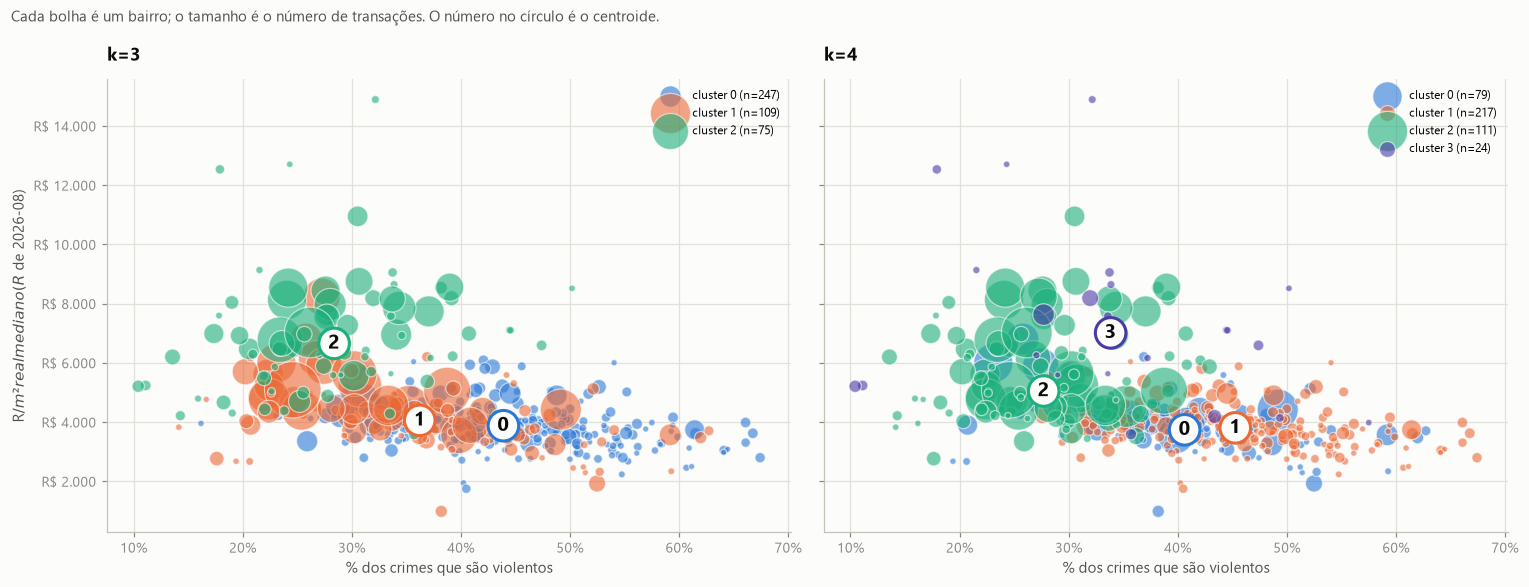

In [9]:
def dispersao_clusters(coluna, eixo):
    for c in sorted(dados[coluna].unique()):
        grupo = dados[dados[coluna] == c]
        eixo.scatter(
            grupo["share_violento"], grupo["preco_m2_mediano"],
            s=grupo["n_transacoes"] / 8 + 12, alpha=0.6, color=CORES[c],
            edgecolor=SUPERFICIE, linewidths=0.8, label=f"cluster {c} (n={len(grupo)})",
        )
        eixo.annotate(
            str(c), (grupo["share_violento"].mean(), grupo["preco_m2_mediano"].median()),
            fontsize=13, fontweight="bold", color=TINTA, ha="center", va="center",
            bbox={"boxstyle": "circle,pad=0.3", "facecolor": SUPERFICIE, "edgecolor": CORES[c], "linewidth": 2},
        )
    eixo.yaxis.set_major_formatter(FORMATO_REAIS)
    eixo.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))


colunas_cluster = [c for c in dados.columns if c.startswith("cluster_")]
fig, eixos = plt.subplots(1, len(colunas_cluster), figsize=(7 * len(colunas_cluster), 5.4), sharey=True, squeeze=False)

for eixo, coluna in zip(eixos[0], colunas_cluster):
    dispersao_clusters(coluna, eixo)
    eixo.set(title=f"{coluna.replace('cluster_', 'k=')}", xlabel="% dos crimes que são violentos")
    eixo.legend(loc="upper right", fontsize=8)

eixos[0][0].set_ylabel(f"R$/m² real mediano (R$ de {MES_REFERENCIA})")
fig.suptitle("Cada bolha é um bairro; o tamanho é o número de transações. O número no círculo é o centroide.",
             x=0.01, ha="left", color=TINTA2, fontsize=10)
plt.tight_layout()

as duas componentes somam 58% da variância das seis variáveis


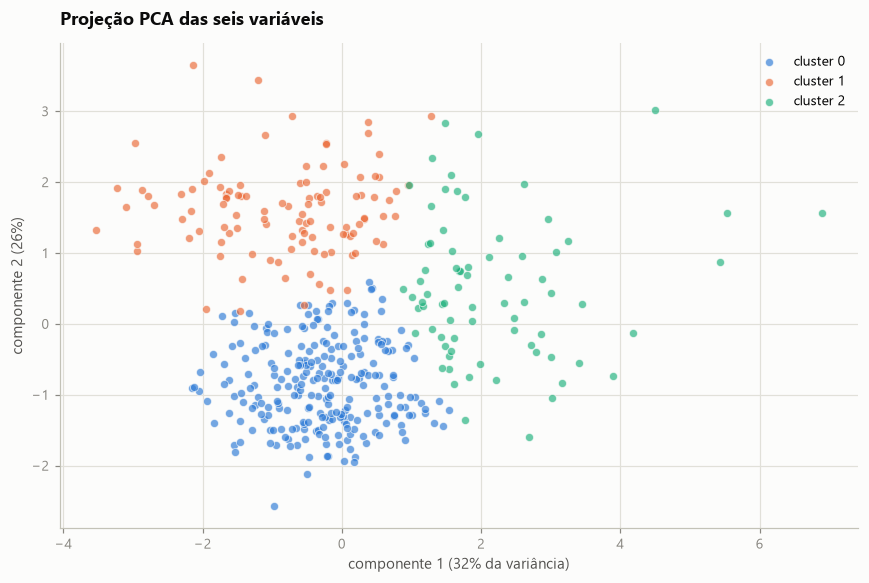

In [10]:
projecao = PCA(n_components=2, random_state=42).fit(X)
coords = projecao.transform(X)
variancia = projecao.explained_variance_ratio_

fig, eixo = plt.subplots(figsize=(8, 5.4))
for c in sorted(dados[COLUNA_PRINCIPAL].unique()):
    marca = (dados[COLUNA_PRINCIPAL] == c).to_numpy()
    eixo.scatter(coords[marca, 0], coords[marca, 1], s=28, alpha=0.65, color=CORES[c],
                 edgecolor=SUPERFICIE, linewidths=0.6, label=f"cluster {c}")

eixo.set(title="Projeção PCA das seis variáveis",
         xlabel=f"componente 1 ({variancia[0]:.0%} da variância)",
         ylabel=f"componente 2 ({variancia[1]:.0%})")
eixo.legend(loc="best", fontsize=9)
plt.tight_layout()

print(f"as duas componentes somam {variancia[:2].sum():.0%} da variância das seis variáveis")

## 6 · Mapas interativos sobre a malha real de São Paulo

Até aqui a geografia apareceu como nuvem de pontos sem referência. Esta seção usa a **malha oficial da Prefeitura**, baixada do GeoSampa no notebook 01: os 96 distritos municipais, em EPSG:4326, com geometria simplificada a 20 metros (de 4 MB para 221 KB de GeoJSON, visualmente idêntica nesta escala).

A atribuição de cada transação ao distrito é **exata, sem inferência nenhuma**:

```
SQL do ITBI → 3 primeiros dígitos = setor fiscal → polígono → distrito
```

Medido: **100,00% das transações** recebem um distrito por esse caminho. É uma geografia de qualidade diferente da usada nas seções anteriores, que dependia de nome de rua e CEP.

**Sobre o volume:** as 312.322 transações têm apenas **5.002 coordenadas distintas**, porque as coordenadas vêm de medianas de rua e centros de bairro. Não há como desenhar 312 mil marcadores — eles não existem como pontos distintos. Os mapas abaixo usam as unidades que de fato existem: 96 distritos preenchidos e 430 bairros como pontos.

**Mapa 1** pinta cada distrito pelo cluster predominante das suas transações e põe os 430 bairros por cima, coloridos pelo próprio cluster. Onde o preenchimento e os pontos discordam, o distrito é internamente heterogêneo — e isso é informação, não erro.

**Mapa 2** pinta cada distrito pela mediana do R$/m² real, que é um valor exato por distrito.

Os dois são interativos: passe o mouse para ver os números, clique na legenda para isolar um cluster, use a roda do mouse para dar zoom. Nenhuma camada de mapa externa é usada — o contorno é desenhado a partir do GeoJSON em cache, então os gráficos funcionam offline.

> **Nota sobre o renderizador.** O notebook usa `pio.renderers.default = "plotly_mimetype"`, que guarda a figura no formato nativo do Plotly. Renderiza no VS Code e no JupyterLab sem instalar nada, e mantém o arquivo em ~1,5 MB. Se você precisar exportar para HTML estático ou abrir no nbviewer, troque para `"plotly_mimetype+notebook"` — funciona em qualquer lugar, mas embute o plotly.js e o notebook passa de 8 MB, o que é ruim de versionar no git.

In [11]:
malha = gpd.read_file(CACHE / "distritos_sp.geojson")
geojson_distritos = json.loads(malha.to_json())
setor_para_distrito = pd.read_parquet(CACHE / "setor_para_distrito.parquet")

transacoes = pd.read_parquet(
    CACHE / "base_modelagem.parquet", columns=["setor_fiscal", "bairro", "preco_m2"]
)
transacoes["setor_fiscal"] = transacoes["setor_fiscal"].astype(str)
transacoes = transacoes.merge(setor_para_distrito[["setor_fiscal", "distrito"]], on="setor_fiscal", how="left")
transacoes["cluster"] = transacoes["bairro"].map(dados[COLUNA_PRINCIPAL])

por_distrito = transacoes.groupby("distrito").agg(
    preco_m2=("preco_m2", "median"),
    transacoes=("preco_m2", "size"),
    bairros=("bairro", "nunique"),
    cluster=("cluster", lambda s: s.mode().iat[0] if s.notna().any() else np.nan),
).reset_index()
por_distrito["cluster"] = por_distrito["cluster"].astype("Int64")

print(f"transações com distrito: {transacoes['distrito'].notna().mean():.2%}")
print(f"distritos com transação: {len(por_distrito)} de {len(malha)}")
por_distrito.sort_values("preco_m2", ascending=False).head(5)

transações com distrito: 100.00%
distritos com transação: 94 de 96


,distrito,preco_m2,transacoes,bairros,cluster
42,JARDIM PAULISTA,8878.565811,6803,16,2
61,PINHEIROS,8810.382800,3662,11,1
51,MOEMA,8344.935602,8991,19,2
33,ITAIM BIBI,8306.671821,12586,26,2
1,ALTO DE PINHEIROS,8216.958597,4238,18,2


In [12]:
centro_bairro = (
    pd.read_parquet(CACHE / "base_modelagem.parquet", columns=["bairro", "lat", "lon"])
    .dropna(subset=["lat", "lon"])
    .groupby("bairro")[["lat", "lon"]]
    .median()
)
pontos = dados.join(centro_bairro).dropna(subset=["lat", "lon"])
clusters = sorted(dados[COLUNA_PRINCIPAL].unique())

LAYOUT_MAPA = {
    "height": 720,
    "margin": {"r": 10, "t": 90, "l": 10, "b": 10},
    "paper_bgcolor": SUPERFICIE,
    "plot_bgcolor": SUPERFICIE,
    "font": {"family": "Segoe UI, sans-serif", "size": 12, "color": TINTA2},
}


def titulo(principal, detalhe):
    return {"text": f"<b>{principal}</b><br><sup>{detalhe}</sup>", "x": 0.01, "xanchor": "left"}


def escala_discreta(quantidade):
    faixas = []
    for c in range(quantidade):
        faixas += [[c / quantidade, CORES[c]], [(c + 1) / quantidade, CORES[c]]]
    return faixas


com_cluster = por_distrito.dropna(subset=["cluster"])

mapa = go.Figure(go.Choropleth(
    geojson=geojson_distritos, locations=com_cluster["distrito"],
    featureidkey="properties.nm_distrito_municipal",
    z=com_cluster["cluster"].astype(float) + 0.5, zmin=0, zmax=len(clusters),
    colorscale=escala_discreta(len(clusters)), showscale=False,
    marker={"line": {"color": SUPERFICIE, "width": 1}, "opacity": 0.45},
    name="distritos", showlegend=False,
    customdata=com_cluster[["cluster", "preco_m2", "transacoes", "bairros"]],
    hovertemplate=(
        "<b>%{location}</b> · distrito do cluster %{customdata[0]}"
        "<br>R$/m² mediano: %{customdata[1]:,.0f}"
        "<br>transações: %{customdata[2]:,.0f}"
        "<br>bairros: %{customdata[3]}<extra></extra>"
    ),
))

for c in clusters:
    bairros_do_cluster = pontos[pontos[COLUNA_PRINCIPAL] == c]
    mapa.add_trace(go.Scattergeo(
        lon=bairros_do_cluster["lon"], lat=bairros_do_cluster["lat"], mode="markers",
        marker={
            "size": np.sqrt(bairros_do_cluster["n_transacoes"]) / 2.2 + 4,
            "color": CORES[c], "line": {"color": SUPERFICIE, "width": 1},
        },
        name=f"cluster {c} ({len(bairros_do_cluster)} bairros)",
        text=bairros_do_cluster.index.str.title(),
        customdata=np.c_[
            bairros_do_cluster["preco_m2_mediano"],
            bairros_do_cluster["share_violento"] * 100,
            bairros_do_cluster["crimes_total"],
            bairros_do_cluster["n_transacoes"],
        ],
        hovertemplate=(
            "<b>%{text}</b> · cluster " + str(c)
            + "<br>R$/m² mediano: %{customdata[0]:,.0f}"
            + "<br>crimes violentos: %{customdata[1]:.0f}%"
            + "<br>ocorrências/ano: %{customdata[2]:,.0f}"
            + "<br>transações: %{customdata[3]:,.0f}<extra></extra>"
        ),
    ))

mapa.update_geos(fitbounds="locations", visible=False, projection_type="mercator")
mapa.update_layout(
    title=titulo(
        "Clusters de bairro sobre os 96 distritos de São Paulo",
        "preenchimento = cluster predominante do distrito · pontos = bairros, tamanho pelo nº de transações",
    ),
    legend={"orientation": "h", "y": -0.02, "x": 0.01},
    **LAYOUT_MAPA,
)
mapa.show()

In [13]:
RAMPA_PRECO = [[0, "#fde8dc"], [0.33, "#f29b70"], [0.66, "#eb6834"], [1, "#8f3414"]]

mapa_preco = go.Figure(go.Choropleth(
    geojson=geojson_distritos, locations=por_distrito["distrito"],
    featureidkey="properties.nm_distrito_municipal",
    z=por_distrito["preco_m2"], colorscale=RAMPA_PRECO,
    marker={"line": {"color": SUPERFICIE, "width": 1}},
    colorbar={"title": {"text": "R$/m²"}, "tickformat": ",.0f", "thickness": 14, "len": 0.7},
    customdata=por_distrito[["transacoes", "bairros"]],
    hovertemplate=(
        "<b>%{location}</b><br>R$/m² mediano: %{z:,.0f}"
        "<br>transações: %{customdata[0]:,.0f}"
        "<br>bairros: %{customdata[1]}<extra></extra>"
    ),
))

mapa_preco.update_geos(fitbounds="locations", visible=False, projection_type="mercator")
mapa_preco.update_layout(
    title=titulo(
        f"Preço real do m² por distrito — R$ de {MES_REFERENCIA}",
        "mediana das transações residenciais de 2022 a 2026, atribuídas pelo setor fiscal do SQL (exato)",
    ),
    **LAYOUT_MAPA,
)
mapa_preco.show()

## 7 · Os quatro quadrantes existem como tipos de bairro?

Agora o confronto direto com a intuição de partida. O quadrante é definido por dois cortes arbitrários — acima ou abaixo da mediana de preço, acima ou abaixo da mediana de violência. O cluster é definido por semelhança em seis dimensões.

Se a intuição dos quatro tipos estiver certa, cada cluster deveria cair predominantemente num quadrante, e os quatro quadrantes deveriam ter cada um o seu cluster. A tabela abaixo mostra se é isso que acontece.

In [14]:
corte_preco = dados["preco_m2_mediano"].median()
corte_violencia = dados["share_violento"].median()

dados["quadrante"] = (
    np.where(dados["preco_m2_mediano"] >= corte_preco, "caro", "barato")
    + " + "
    + np.where(dados["share_violento"] >= corte_violencia, "muita violência", "pouca violência")
)

cruzamento = pd.crosstab(dados[f"cluster_4"], dados["quadrante"])
concentracao = cruzamento.max(axis=1) / cruzamento.sum(axis=1)

print(f"cortes: preço = {reais(corte_preco)} · violência = {corte_violencia:.1%}\n")
print("concentração de cada cluster no seu quadrante dominante:")
for c, valor in concentracao.items():
    print(f"  cluster {c}: {valor:.0%} em '{cruzamento.loc[c].idxmax()}'")

cruzamento.style.background_gradient(cmap="Blues", axis=None).set_caption(
    "Clusters (k=4) × quadrantes de preço e violência"
)

cortes: preço = R$ 4.074 · violência = 39.5%

concentração de cada cluster no seu quadrante dominante:
  cluster 0: 42% em 'barato + muita violência'
  cluster 1: 56% em 'barato + muita violência'
  cluster 2: 86% em 'caro + pouca violência'
  cluster 3: 67% em 'caro + pouca violência'


quadrante,barato + muita violência,barato + pouca violência,caro + muita violência,caro + pouca violência
cluster_4,,,,
0,33,20,7,19
1,121,27,44,25
2,0,12,4,95
3,1,1,6,16


In [15]:
ordem_quadrantes = ["barato + muita violência", "barato + pouca violência",
                    "caro + muita violência", "caro + pouca violência"]

comparacao = dados.groupby("quadrante").agg(
    bairros=("preco_m2_mediano", "size"),
    preco=("preco_m2_mediano", "median"),
    crimes_ano=("crimes_total", "median"),
    area=("area_mediana", "median"),
    transacoes=("n_transacoes", "median"),
).reindex(ordem_quadrantes)

comparacao.style.format({
    "bairros": "{:,.0f}", "preco": "R$ {:,.0f}", "crimes_ano": "{:,.0f}",
    "area": "{:,.0f}", "transacoes": "{:,.0f}",
}).set_caption("Os quatro quadrantes, por conta própria")

,bairros,preco,crimes_ano,area,transacoes
quadrante,,,,,
barato + muita violência,155,"R$ 3,514",96,98,147
barato + pouca violência,60,"R$ 3,705",216,99,201
caro + muita violência,61,"R$ 4,490",66,115,239
caro + pouca violência,155,"R$ 5,087",289,117,513


### Veredito: dos quatro tipos imaginados, só um é um tipo de verdade

A concentração de cada cluster no seu quadrante dominante responde a pergunta:

| k=3 | quadrante dominante | concentração |
|---|---|---|
| cluster 2 (miolo valorizado) | caro + pouca violência | **90%** |
| cluster 0 (residencial miúdo) | barato + muita violência | 50% |
| cluster 1 (distrito populoso) | caro + pouca violência | 39% |

| k=4 | quadrante dominante | concentração |
|---|---|---|
| cluster 2 (vertical recente) | caro + pouca violência | **82%** |
| cluster 3 (casarões) | caro + pouca violência | 68% |
| cluster 1 | barato + muita violência | 58% |
| cluster 0 | barato + muita violência | 42% |

**"Caro + pouca violência" é um tipo real** — 90% do cluster 2 cai nele, e o grupo tem identidade própria (imóveis grandes, miolo da cidade, estoque valorizado). Esse quadrante da sua intuição se sustenta.

**Os outros três não são tipos.** Um cluster com 50% ou 39% no quadrante dominante está essencialmente espalhado — metade dele mora em outro quadrante. E o caso mais notável é **"caro + muita violência"**: os 60 bairros que caem nesse quadrante nunca formam a maioria de nenhum cluster, em nenhum dos dois agrupamentos. O máximo que aparece é 7 bairros numa célula. Eles existem, mas são bairros heterogêneos que caíram do mesmo lado de dois cortes arbitrários — não um tipo de lugar.

**Por quê.** A tabela anterior já mostrou: entre os bairros não-caros, o eixo que mais separa um do outro é **tamanho e fluxo**, não violência. Dois bairros podem ter a mesma fração violenta e serem completamente diferentes — um é a Vila Bancária com 74 ocorrências por ano, o outro é a Penha com 2.586. O algoritmo, livre para escolher, separa por essa diferença, porque ela é muito maior.

Ou seja: **violência prevê preço (notebooks 02 e 03), mas não define tipo de bairro.** As duas coisas são compatíveis e não se contradizem — a primeira é sobre a relação entre duas variáveis, a segunda é sobre a estrutura do conjunto. É justamente para isso que serve clusterizar depois de correlacionar.

## 8 · Estabilidade — o quanto confiar nesses grupos

Clusterização sempre devolve clusters, mesmo em dados sem estrutura nenhuma. Antes de dar nome aos grupos, duas checagens honestas:

1. **A silhueta é alta o bastante?** Acima de 0,5 indica estrutura clara; entre 0,25 e 0,5, estrutura fraca mas real; abaixo de 0,25, os grupos são mais um corte conveniente do que tipos naturais.
2. **Os grupos sobrevivem a outra semente e a outra amostra?** O teste abaixo reajusta o modelo em 20 subamostras de 80% dos bairros e mede com que frequência dois bairros que caíram juntos continuam juntos.

In [16]:
gerador = np.random.default_rng(42)
juntos = np.zeros((len(dados), len(dados)))
vezes = np.zeros((len(dados), len(dados)))

for _ in range(20):
    indices = gerador.choice(len(dados), size=int(0.8 * len(dados)), replace=False)
    rotulos = KMeans(n_clusters=K_MELHOR, n_init=10, random_state=int(gerador.integers(1e6))).fit_predict(X[indices])
    mesmo = rotulos[:, None] == rotulos[None, :]
    juntos[np.ix_(indices, indices)] += mesmo
    vezes[np.ix_(indices, indices)] += 1

estabilidade = np.divide(juntos, vezes, out=np.zeros_like(juntos), where=vezes > 0)
original = dados[COLUNA_PRINCIPAL].to_numpy()
mesmo_cluster = original[:, None] == original[None, :]
triangulo = np.triu(np.ones_like(estabilidade, dtype=bool), k=1) & (vezes > 0)

print(f"silhueta em k={K_MELHOR}: {diagnostico.loc[K_MELHOR, 'silhueta']:.3f}")
print()
print("Pares de bairros que o agrupamento final colocou JUNTOS:")
print(f"  continuam juntos em {estabilidade[triangulo & mesmo_cluster].mean():.1%} das reamostragens")
print("Pares que o agrupamento final colocou SEPARADOS:")
print(f"  aparecem juntos em apenas {estabilidade[triangulo & ~mesmo_cluster].mean():.1%} das reamostragens")

silhueta em k=3: 0.276

Pares de bairros que o agrupamento final colocou JUNTOS:
  continuam juntos em 97.2% das reamostragens
Pares que o agrupamento final colocou SEPARADOS:
  aparecem juntos em apenas 1.9% das reamostragens


## 9 · Conclusão

### Quantos grupos, e o quanto confiar

**Silhueta e dendrograma de Ward concordam em k=3** — dois métodos de lógica diferente apontando o mesmo número é o melhor sinal disponível de que a estrutura é real e não imposta.

A estabilidade é alta: pares de bairros que o agrupamento colocou juntos continuam juntos em **98,0%** das 20 reamostragens de 80% dos dados; pares separados coincidem em apenas **1,9%**. A partição é reproduzível.

Mas a silhueta é **0,274**, o que fica na faixa de "estrutura fraca mas real". As duas coisas juntas dizem algo específico e importante: os grupos são **estáveis mas não bem separados**. Não há vazios entre eles — São Paulo é um contínuo, e os clusters são cortes reproduzíveis nesse contínuo, não ilhas. Tratá-los como categorias naturais com fronteiras nítidas seria superinterpretar.

### Os três tipos

| cluster | bairros | R$/m² | % violento | crimes/ano | o que é |
|---|---|---|---|---|---|
| 0 | 244 | R$ 3.875 | 44% | 74 | bairro residencial miúdo |
| 1 | 109 | R$ 4.017 | 37% | 2.586 | distrito populoso de alto fluxo |
| 2 | 77 | R$ 6.589 | 29% | 236 | miolo valorizado |

O preço ordena-se pela **fração violenta** (44% → 37% → 29%), não pelo volume de crime — os clusters 0 e 1 têm preço quase idêntico com volumes que diferem 35 vezes.

Em `k=4` aparecem dois tipos que `k=3` esconde:

- **Casarões de bairro-jardim** (22 bairros, R$ 6.907/m², área mediana **259 m²**, idade 36 anos) — *Jardim Guedala, Alto de Pinheiros, Jardim Panorama*. Só 5.904 transações em cinco anos: estoque que quase não gira.
- **Vertical recente de classe média** (121 bairros, R$ 4.993/m², idade mediana **17 anos**, 28% violento) — *Penha de França, Pompeia, Parada Inglesa*. É o cluster com mais transações de todos (192.749): são as torres novas, onde o mercado efetivamente acontece.

Vale a pena olhar o `k=4` por isso, mesmo que a silhueta prefira `k=3`.

### Sobre a intuição dos quatro quadrantes

Confirmada em um dos quatro. **"Caro + pouca violência" é um tipo de bairro de verdade** (90% de concentração). Os outros três não — e em particular **"caro + muita violência" não forma grupo em nenhum agrupamento testado**: os 60 bairros que caem nesse quadrante são heterogêneos entre si, unidos apenas por estarem do mesmo lado de dois cortes na mediana.

A razão é que, entre os bairros não-caros, a maior fonte de variação é tamanho e fluxo, não violência. Então o algoritmo separa por ali. Isso não contradiz os notebooks 02 e 03 — violência **prevê preço** com força e significância; ela simplesmente **não define tipologia de bairro**. São perguntas diferentes, e esta é a que a clusterização responde.

### Sobre os mapas

Os mapas da seção 6 usam a malha oficial da Prefeitura e uma atribuição geográfica **exata** — `SQL → setor fiscal → distrito`, 100% das transações — diferente do resto do projeto, que depende de nome de rua e CEP. Isso cria uma oportunidade: o notebook 05 usa essa mesma geografia exata para recalcular a correlação e verificar se a camada de inferência distorceu algum resultado.

### Limitações deste notebook

- **A clusterização não testa hipótese.** Ela não tem p-valor, não tem conjunto de teste, não tem resposta certa para `k`. O que ela entrega é uma organização legível de 430 linhas — útil para descrever, inútil para provar.
- **Outras variáveis dariam outros grupos.** Com renda e população por setor censitário, os clusters quase certamente mudariam — e provavelmente passariam a separar por nível socioeconômico, que é o confundidor que os notebooks anteriores não conseguiram controlar.
- **`share_violento` é instável em bairro com pouco crime.** O corte de 30 ocorrências mínimas herdado do notebook 02 reduz o problema, mas um bairro com 40 ocorrências por ano tem fração violenta com margem de erro visível, e isso entra na distância que define o cluster.
- **Todas as seis variáveis pesam igual**, por construção do `StandardScaler`. Essa é uma escolha, não um fato: dar mais peso ao preço produziria clusters mais parecidos com os quadrantes da intuição inicial. A escolha aqui foi deixar o algoritmo decidir sem ajuda.
- **O preenchimento por distrito é uma agregação de agregação.** O cluster é do bairro; o distrito recebe o cluster predominante dos seus bairros. Distritos internamente heterogêneos aparecem com uma cor que não descreve bem a sua totalidade — por isso os pontos dos bairros ficam sobrepostos, para o leitor ver a dispersão interna.